# Overfitting Model

by Niklas Vogel and Kevin Stupar

GitHub: https://github.com/Nukufel/AiAp_MiniProj_1

This notebook creates an overfitting model and evaluates it.
We used the `intel image classfification` data for thrainging out model.

It does the same, as the underfitting, just with a different model.

## Steps
- Loading, splitting and inspection of the data
- Preparing the model and fitting it
- Evaluate the model

## Setup
Before executing this please make sure you did download and extract the [data](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc).
The Data must look like this: `./.cache/extracted/seg_train/seg_train/`

Alternatively you can run `setup.py`

## Data Credit
- Initially published on https://datahack.analyticsvidhya.com
- Downloaded from https://www.kaggle.com/datasets/puneet6060/intel-image-classification
- Photos by [Jan Böttinger on Unsplash](https://unsplash.com/photos/birds-eye-view-photo-of-building-27xFENkt-lc)

# Loading and splitting the data

The dataset contains six categories:
- buildings
- forest
- glacier
- mountain
- sea
- street

All classes have 2000 samples except `street` which has only 150.
This is guaranteed by our setup, which deletes excess images.

The dataset is loaded using the "image_dataset_from_directory" method from keras. This method also resizes the images to `64*64` pixels.
Next we shuffle the data using a seed so there is randomness in which go into training, validation and test split.
Using the seed we ensure the splits look the same for all models, but can be changed using the seed.

After shuffling we split the data into training, validation and test data.
- training: 56% (80% of non-test)
- validation: 14% (20% of non-test)
- test: 30%

In [7]:
from helper import *
from tensorflow.keras import layers, models

image_size = (64, 64)
batch_size = 32

(all_images, train_images, validation_images, test_images, label_names) = get_data(image_size)

Number of training images:  5683
Number of validation images:  1420
Number of testing images:  3045
Class names:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


# Inspecting the data

Before we train the model we want to know how the data looks like so we know what we are dealing with.
Since we only have 150 streets, we will probably not see them here, but note that the images of streets often include buildings on the side.
This will be important later on.

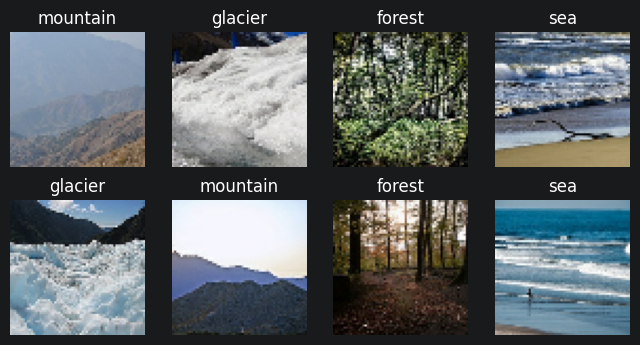

In [2]:
plot_samples(all_images, label_names)

Here we can see that all classes have exactly 2000 images, except for street, which only has 150 images.

Also we can see that all splits have about an equal amount of each class.

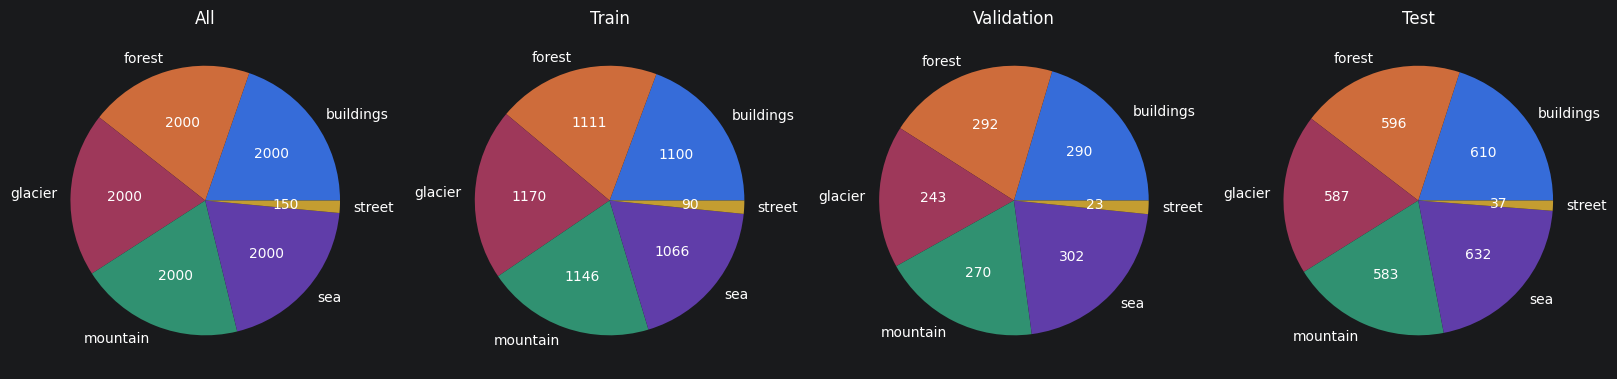

In [3]:
plot_numbers_per_classes({"All": all_images, "Train": train_images, "Validation": validation_images, "Test": test_images}, label_names)

# Building the model

Since we want an overfitting model (ca. 100'000 parameters) we use 5 layers.
More convolutional layers mean more feature extraction which can lead to overfitting.
We also add more filters (kernels) per convolutional layer so even more features get extracted.
Between each layer we scale down the image using a max pooling to reduce the amount of parameters otherwise the training of the model would take ages.
By keeping MaxPooling same we try to keep as much information until the end, so the model can learn image specific features.
In the last layer we flatten the image from two dimensions into one and feed it onto a Dense layer.

As we can see in the summary below, the second layer has the most parameters, since the previous layer has 256 kernels.

In [4]:
model = models.Sequential([
    layers.Input(shape=image_size + (3,)),
    layers.Rescaling(1./255),
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 128)    │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 135,846 (530.65 KB)

 Trainable params: 135,846 (530.65 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Here we compile the model and train it using the train and validation data.
We chose to use 30 Epochs here, so we can see clearly that the model is overfitting.

The training will take a while, why we recommend to use linux, since it is multiple times faster than windows.

In [5]:
history = model.fit(train_images.batch(batch_size), epochs=30, validation_data=validation_images.batch(batch_size))

Epoch 1/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - accuracy: 0.5110 - loss: 1.2018 - val_accuracy: 0.5444 - val_loss: 1.1566
Epoch 2/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.6152 - loss: 0.9671 - val_accuracy: 0.6359 - val_loss: 0.9852
Epoch 3/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.6738 - loss: 0.8573 - val_accuracy: 0.6880 - val_loss: 0.8333
Epoch 4/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7218 - loss: 0.7595 - val_accuracy: 0.7810 - val_loss: 0.6542
Epoch 5/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7552 - loss: 0.6742 - val_accuracy: 0.7746 - val_loss: 0.6459
Epoch 6/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7786 - loss: 0.6124 - val_accuracy: 0.7894 - val_loss: 0.5982
Epoch 7/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.7948 - loss: 0.5572 - val_accuracy: 0.8120 - val_loss: 0.5550
Epoch 8/30
178/178 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8159 - loss: 0.5139 - val_accu

# Evaluating the model

## Preparing
To evaluate the model we first run some images through the model and look at the predictions the model has made.

After that we use those prediction together with the true values to plot some graphs and evaluate how good the models behaves and if it really overfits.

## Plots
### Accuracy/Loss
The first two plots show us the accuracy and the loss, where the loss is in a log y-scale, to better see the difference between the Epochs.

### Confusion Matrix
We have 4 different confusion matrices plotted, On the y-scale we have th actual labes and on the x-scale is what the model predicted.

### Scores
The last three plots show us some important training metrics such as f1-score, precision and recall.

Validation accuracy: 0.8021126985549927
Validation Loss: 1.2768385410308838


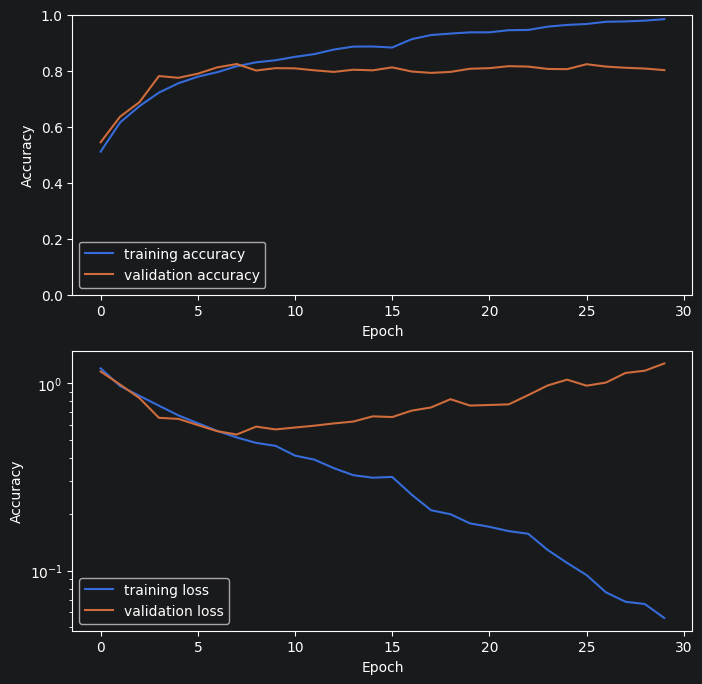

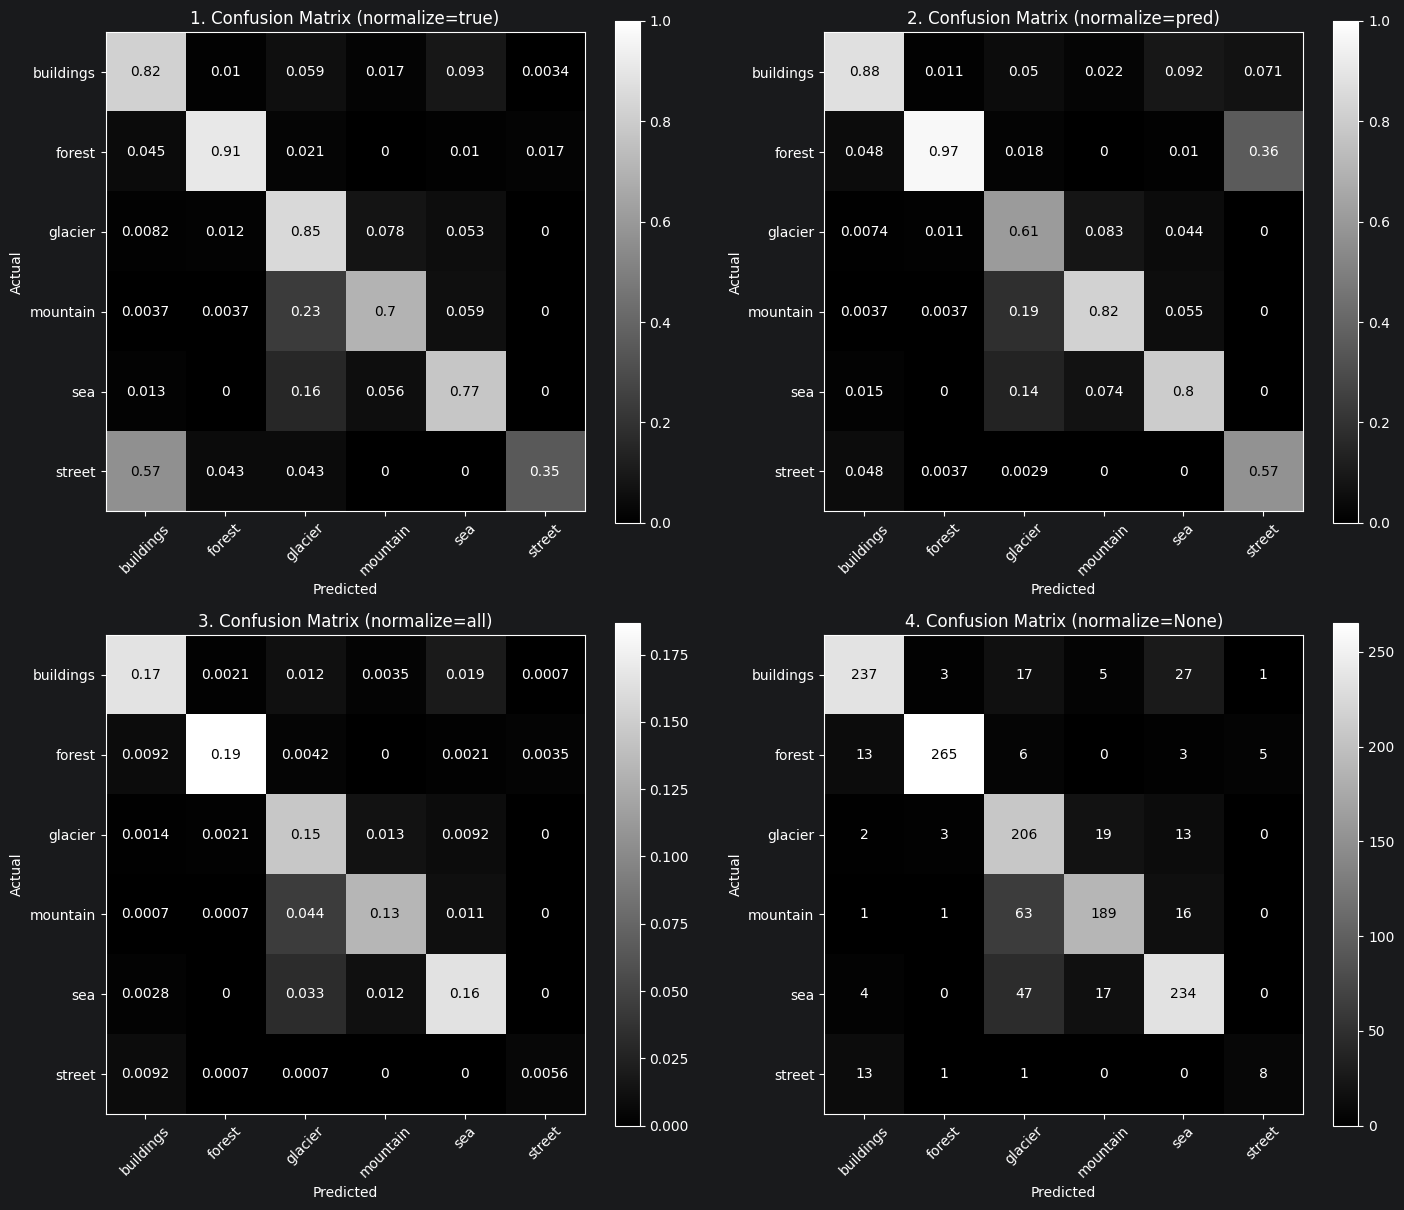

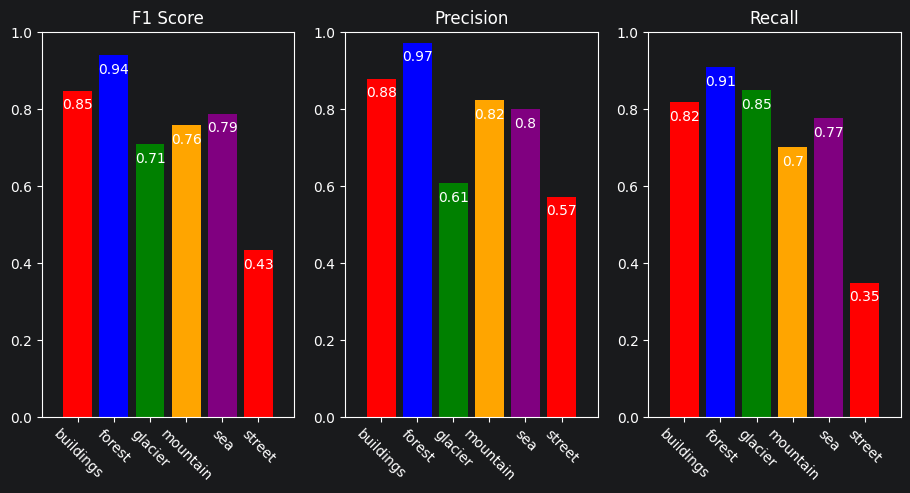

In [6]:
true, pred, pred_raw = calculate_predictions(model, validation_images.batch(batch_size))

print_accuracy_and_loss(model, validation_images.batch(batch_size))
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])
plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)

# Discussion
- Overall performance: The model has a training accuracy of nearly 1 and a validation accuracy of about 0.79. Training accuracy being significantly higher than validation accuracy means our model is overfitting.
- Accuracy: The training and validation accuracy go their own ways almost immediately. This means our model learns random noise only specific to our training data from the images, which leads to high variance.
- Loss: The training loss gets close to 0 so on training data our model predicts very good. But interesting here is that the validation loss stays high so out model is not able to determine those images correctly.
- Confusion Matrix:
  1. Most interesting is that a streets always gets predicted either as building or forest so our model did not learn what a street is at all and is wors than the underfitting model.
  2. Looking at street again we see that most street predictions are actually buildings. This might not just be because the model is bad but also many buildings have streets in their image making it extra hard. Our model seams to struggle with differentiating between a glacier and mountain (also seen in 1.). This is probably due to the fact that glaciers apper in mountains.
  3. Here we see that no class really dominates the models performance all classes except street get predicted quite well.
  4. This shows the massive imbalance in our dataset with street class having significantly fewer samples.
- Training metrics
    - F1 score: This tells us how balanced our model is, which is again not very good because of the street samples.
    - Precision: Here we see somthing interesting the scores of all classes is quite similar to our underfitting model except street which is much worse, probably because the model does not generalize well.
    - Recall: The recall tells us again that only a tiny amount of streets even get classified as such.